# Mental Health Text Classification with SVM
### Vectorizers: CamemBERT (HuggingFace) + TF-IDF | Classifier: SVM (class-based) with GridSearch

## 1. Libraries

In [1]:
# =========================
# Import Libraries
# =========================
import pandas as pd
import numpy as np

# Sklearn
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline

# PyTorch + HuggingFace
import torch
from transformers import CamembertTokenizer, CamembertModel
from tqdm import tqdm

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

The first cell imports all the necessary tools for the project. Pandas and NumPy handle data loading and numerical operations. From Scikit-learn, we import the train-test splitter, label encoder, SVM classifier, TF-IDF vectorizer, GridSearchCV for hyperparameter tuning, and various evaluation metrics. From HuggingFace Transformers, we import the CamemBERT tokenizer and model, which serve as our deep learning vectorizer. PyTorch is used as the backend to run CamemBERT computations, with GPU support if available. Finally, Seaborn and Matplotlib handle visualization, and tqdm displays progress bars during the embedding process.

## 2. Load & Clean Dataset

In [4]:
# =========================
# Load and Clean Dataset
# =========================
data = pd.read_csv(r'C:\Users\Admin\Documents\FYP\french dataset\Code\EDA\MyResults\french_cleaned.csv')

# Remove rows with missing text or labels
data = data.dropna(subset=['text', 'mental_state'])
data['text'] = data['text_nostop'].astype(str)

print(f"Dataset shape: {data.shape}")
print(f"Label distribution:\n{data['mental_state'].value_counts()}")
data.head()

Dataset shape: (6022, 22)
Label distribution:
mental_state
Healthy      3209
Unhealthy    2813
Name: count, dtype: int64


,text,word_count,language,category,age,education_level,formality,context,mental_state,text_length,...,hashtags,tokens,char_count,punct_count,question_count,exclamation_count,ellipsis_count,text_nostop,emoji_count,emoticon_count
0,valeur transcend moment sombre,6,French,Self-Worth,young adult (20-29),professional,highly formal academic,text message to friend,Healthy,6,...,[],"['valeur', 'transcend', 'moment', 'sombre']",40,0,0,0,0,valeur transcend moment sombre,0,0
1,mérite vivre pleinement jour,7,French,Self-Worth,elderly (60+),primary education,formal,diary entry,Healthy,7,...,[],"['mérite', 'vivre', 'pleinement', 'jour']",41,0,0,0,0,mérite vivre pleinement jour,0,0
2,mérite vivre vrai,6,French,Self-Worth,adult (30-45),primary education,very informal with slang,text message to friend,Healthy,6,...,[],"['mérite', 'vivre', 'vrai']",29,1,0,1,0,mérite vivre vrai,0,0
3,mérite vivre pleinement,5,French,Self-Worth,adult (30-45),high school,very informal with slang,therapy session,Healthy,5,...,[],"['mérite', 'vivre', 'pleinement']",29,0,0,0,0,mérite vivre pleinement,0,0
4,mérite vivre jour,6,French,Self-Worth,elderly (60+),primary education,casual,forum post,Healthy,6,...,[],"['mérite', 'vivre', 'jour']",30,0,0,0,0,mérite vivre jour,0,0


## 3. Encode Labels

In [5]:
# =========================
# Encode Labels
# =========================
label_encoder = LabelEncoder()
data['encoded_label'] = label_encoder.fit_transform(data['mental_state'])

print("Label mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))
data[['mental_state', 'encoded_label']].head(150)

Label mapping: {'Healthy': np.int64(0), 'Unhealthy': np.int64(1)}


,mental_state,encoded_label
0,Healthy,0
1,Healthy,0
2,Healthy,0
3,Healthy,0
4,Healthy,0
...,...,...
145,Healthy,0
146,Healthy,0
147,Healthy,0
148,Healthy,0


## 4. Train-Test Split

In [6]:
# =========================
# Train-Test Split
# =========================
X_train_texts, X_test_texts, y_train, y_test = train_test_split(
    data['text_nostop'],
    data['encoded_label'],
    test_size=0.2,
    random_state=42,
    stratify=data['encoded_label']
)

print(f"Train size: {len(X_train_texts)} | Test size: {len(X_test_texts)}")

Train size: 4817 | Test size: 1205


## 5. CamemBERT Vectorizer
> CamemBERT is a French RoBERTa-based model. Used here as a **feature extractor** (not fine-tuned). It produces a 768-dim CLS embedding per sentence.

In [7]:
"""# =========================
# CamemBERT Vectorizer (NOT a class — vectorizers stay functional)
# =========================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load CamemBERT tokenizer and model
camembert_tokenizer = CamembertTokenizer.from_pretrained('camembert-base')
camembert_model = CamembertModel.from_pretrained('camembert-base')
camembert_model.to(device)
camembert_model.eval()"""

# =========================
# CamemBERT Vectorizer (NOT a class — vectorizers stay functional)
# =========================

# Select GPU if available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load CamemBERT tokenizer
# Tokenizer converts text into tokens/numerical IDs
camembert_tokenizer = CamembertTokenizer.from_pretrained('camembert-base')

# Load pretrained CamemBERT model
camembert_model = CamembertModel.from_pretrained('camembert-base')

# Move model to GPU/CPU
camembert_model.to(device)

# Set model to evaluation mode
# Disables dropout and training-specific behavior
camembert_model.eval()

def get_camembert_embeddings(texts, tokenizer, model, device, batch_size=16):
    """
    Extract CLS-token embeddings from CamemBERT for a list of texts.
    Uses batching for efficiency.

    Args:
        texts      : list of strings
        tokenizer  : CamembertTokenizer
        model      : CamembertModel
        device     : torch.device
        batch_size : int, number of sentences per batch

    Returns:
        np.ndarray of shape (n_samples, 768)
    """
    # Store embeddings from all batches

    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="CamemBERT embedding"):
        batch = texts[i : i + batch_size]
        # Tokenize batch
        # truncation=True  -> cut long texts
        # padding=True     -> make all sequences same length
        # max_length=128   -> maximum tokens per text
        # return_tensors   -> return PyTorch tensors
        inputs = tokenizer(
            
            batch,
            return_tensors='pt',
            truncation=True,
            padding=True,
            max_length=128
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        # CLS token: first token of last hidden state
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)

    return np.vstack(all_embeddings)

# =========================
# Generate CamemBERT Embeddings for train and test sets
# =========================
X_train_cam = get_camembert_embeddings(
    X_train_texts.tolist(), camembert_tokenizer, camembert_model, device
)
X_test_cam = get_camembert_embeddings(
    X_test_texts.tolist(), camembert_tokenizer, camembert_model, device
)

print(f"CamemBERT train shape: {X_train_cam.shape}")
print(f"CamemBERT test  shape: {X_test_cam.shape}")

Using device: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
CamemBERT embedding: 100%|██████████| 76/76 [03:17<00:00,  2.60s/it]

CamemBERT train shape: (4817, 768)
CamemBERT test  shape: (1205, 768)


CamemBERT is a French language model based on RoBERTa, pretrained on large French text corpora. 
We load it from HuggingFace using camembert-base and send it to the GPU if one is available, otherwise it runs on CPU. 

"We call model.eval() to disable dropout and other training-specific behaviors, since we are using CamemBERT purely as a feature extractor — we are not training or fine-tuning it."
Neural networks behave differently during training vs testing. 
model.eval() switches it to "testing mode" which makes outputs stable and consistent. We do this because we are not teaching CamemBERT anything new — we are just using its already-learned knowledge to convert sentences into numbers.

"The get_camembert_embeddings() function processes text in batches of 16 for efficiency."
Instead of feeding one sentence at a time (slow), we group 16 sentences together and process them all at once. This makes the embedding step significantly faster.

"For each batch, it tokenizes the text, passes it through the model, and extracts the CLS token."
Three steps happen per batch:

1)Tokenize — splits sentences into smaller units (words/subwords) that CamemBERT understands

2)Pass through the model — CamemBERT processes the tokens and produces rich numerical representations

3)Extract the CLS token — the very first token [CLS] is a special token that CamemBERT uses to summarize the entire sentence into one vector

conclusion : CamemBERT reads each French sentence and converts it into a list of 768 numbers that represent its meaning → the SVM then learns to classify those numbers as Healthy or Unhealthy.

## 6. TF-IDF Vectorizer

In [8]:
# =========================
# TF-IDF Vectorizer (NOT a class — vectorizers stay functional)
# =========================
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_texts)
X_test_tfidf  = tfidf_vectorizer.transform(X_test_texts)

print(f"TF-IDF train shape: {X_train_tfidf.shape}")
print(f"TF-IDF test  shape: {X_test_tfidf.shape}")

TF-IDF train shape: (4817, 5000)
TF-IDF test  shape: (1205, 5000)


TF-IDF (Term Frequency–Inverse Document Frequency) is a classical NLP technique that converts text into numerical vectors based on word importance. 

TF measures how often a word appears in a document, while IDF down-weights words that appear across almost all documents (like common stopwords) and up-weights rare, informative ones. 

We set max_features=5000 to keep only the 5000 most important terms, and ngram_range=(1,2) to capture both single words and two-word phrases (bigrams), which helps preserve some local context.

Crucially, fit_transform() is called only on the training set, and transform() (without fitting) is applied to the test set — this prevents data leakage, ensuring the vectorizer never sees test data during fitting.

## 7. SVM Model Class with GridSearch

In [9]:
# =========================
# SVM Classifier Class
# =========================

class SVMClassifier:
    """
    Support Vector Machine classifier with built-in GridSearch hyperparameter tuning.

    Attributes:
        best_model   : best SVC found by GridSearchCV
        best_params  : dict of best hyperparameters
        cv_results   : full GridSearchCV results dataframe
    """

    # Hyperparameter grid — covers kernel, C (regularization), gamma (for rbf/poly)
    PARAM_GRID = {
        'kernel' : ['rbf', 'poly', 'sigmoid'],
        'C'      : [0.1, 1, 10, 100],
        'gamma'  : ['scale', 'auto'],
    }

    def __init__(self, cv=5, scoring='f1_macro', n_jobs=-1, verbose=1):
        """
        Args:
            cv      : number of cross-validation folds for GridSearch
            scoring : metric to optimise during grid search
            n_jobs  : parallel jobs (-1 = all cores)
            verbose : verbosity level of GridSearchCV
        """
        self.cv      = cv
        self.scoring = scoring
        self.n_jobs  = n_jobs
        self.verbose = verbose

        self.best_model  = None
        self.best_params = None
        self.cv_results  = None

    # ------------------------------------------------------------------
    def fit(self, X_train, y_train):
        """
        Run GridSearchCV over PARAM_GRID and store the best estimator.

        Args:
            X_train : feature matrix (dense or sparse)
            y_train : target labels
        """
        grid_search = GridSearchCV(
            estimator  = SVC(),
            param_grid = self.PARAM_GRID,
            cv         = self.cv,
            scoring    = self.scoring,
            n_jobs     = self.n_jobs,
            verbose    = self.verbose,
            refit      = True   # refit best model on full train set
        )
        grid_search.fit(X_train, y_train)

        self.best_model  = grid_search.best_estimator_
        self.best_params = grid_search.best_params_
        self.cv_results  = pd.DataFrame(grid_search.cv_results_)

        print(f"\nBest params  : {self.best_params}")
        print(f"Best CV score ({self.scoring}): {grid_search.best_score_:.4f}")
        return self

    # ------------------------------------------------------------------
    def predict(self, X):
        """
        Predict class labels.

        Args:
            X : feature matrix
        Returns:
            np.ndarray of predicted labels
        """
        if self.best_model is None:
            raise RuntimeError("Call .fit() before .predict()")
        return self.best_model.predict(X)

    # ------------------------------------------------------------------
    def evaluate(self, X_test, y_test, label_encoder=None, model_name='SVM'):
        """
        Compute evaluation metrics and return a per-class results table.

        Args:
            X_test        : test feature matrix
            y_test        : true labels
            label_encoder : sklearn LabelEncoder (for class names)
            model_name    : string label shown in the Model column

        Returns:
            results_df : DataFrame with columns:
                         Model | Class | Accuracy | Precision | Recall | F1-score | Support | Macro avg
            y_pred     : predicted labels array
        """
        y_pred       = self.predict(X_test)
        target_names = label_encoder.classes_ if label_encoder else None

        # Get full classification report as dict
        report   = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)
        accuracy = accuracy_score(y_test, y_pred)
        macro_f1 = report['macro avg']['f1-score']

        # Build one row per class
        rows = []
        for i, class_name in enumerate(target_names):
            rows.append({
                'Model'     : model_name if i == 0 else '',   # model name only on first row
                'Class'     : class_name,
                'Accuracy'  : round(accuracy, 2) if i == 0 else '',
                'Precision' : round(report[class_name]['precision'], 2),
                'Recall'    : round(report[class_name]['recall'], 2),
                'F1-score'  : round(report[class_name]['f1-score'], 2),
                'Support'   : int(report[class_name]['support']),
                'Macro avg' : round(macro_f1, 2) if i == 0 else '',
            })

        results_df = pd.DataFrame(rows)

        print(f"\n--- {model_name} Evaluation ---")
        print(results_df.to_string(index=False))

        return results_df, y_pred

    # ------------------------------------------------------------------
    def plot_confusion_matrix(self, y_test, y_pred, label_encoder=None):
        """
        Plot a heatmap confusion matrix.

        Args:
            y_test        : true labels
            y_pred        : predicted labels
            label_encoder : sklearn LabelEncoder (for axis labels)
        """
        cm = confusion_matrix(y_test, y_pred)
        labels = label_encoder.classes_ if label_encoder else None

        plt.figure(figsize=(6, 5))
        sns.heatmap(
            cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels,
            cmap='Blues'
        )
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.title('Confusion Matrix — SVM')
        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------------------
    def top_grid_results(self, n=10):
        """Return top-n grid search results sorted by mean test score."""
        cols = ['param_kernel', 'param_C', 'param_gamma',
                'mean_test_score', 'std_test_score', 'rank_test_score']
        return (
            self.cv_results[cols]
            .sort_values('rank_test_score')
            .head(n)
            .reset_index(drop=True)
        )

The SVMClassifier is written as a Python class to make it reusable, clean, and easy to instantiate multiple times with different vectorizers. The class wraps Scikit-learn's SVC (Support Vector Classifier) and adds automatic hyperparameter tuning via GridSearchCV. 

The parameter grid searches over three kernels (rbf, poly, sigmoid), four values of C (the regularization parameter that controls the trade-off between a wider margin and fewer misclassifications), and two gamma settings (scale and auto, which control the influence radius of each training point for non-linear kernels). 

The .fit() method runs all combinations across 5-fold cross-validation and stores the best model. 

The .evaluate() method contains a metrics placeholder that currently computes accuracy and macro F1 — this is where you will plug in your own metrics later. 

The .plot_confusion_matrix() method visualizes prediction errors, and .top_grid_results() returns a ranked table of the best hyperparameter combinations found during the search.

## 8. SVM + CamemBERT Embeddings

SVM with CamemBERT Embeddings
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best params  : {'C': 100, 'gamma': 'scale', 'kernel': 'poly'}
Best CV score (f1_macro): 0.9055

--- SVM + CamemBERT Evaluation ---
          Model     Class Accuracy  Precision  Recall  F1-score  Support Macro avg
SVM + CamemBERT   Healthy     0.92       0.92    0.92      0.92      642      0.92
                Unhealthy                0.91    0.91      0.91      563          


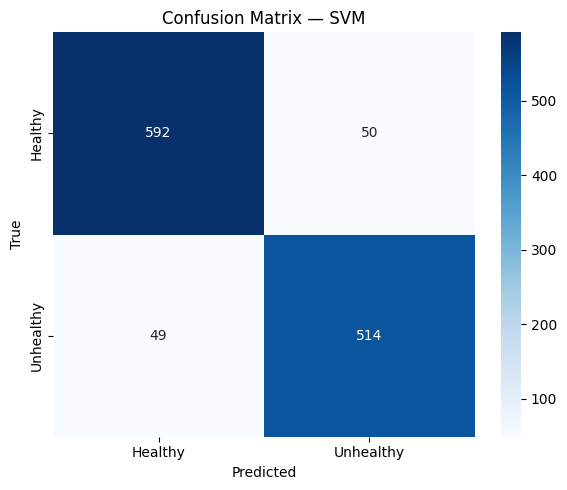


Top 5 Grid Search Results:


,param_kernel,param_C,param_gamma,mean_test_score,std_test_score,rank_test_score
0,poly,100.0,scale,0.905527,0.007964,1
1,poly,10.0,scale,0.905095,0.006826,2
2,rbf,100.0,scale,0.904248,0.006486,3
3,rbf,10.0,scale,0.903186,0.004817,4
4,rbf,100.0,auto,0.885638,0.007190,5


In [10]:
# =========================
# Train & Evaluate: SVM + CamemBERT
# =========================
print("="*50)
print("SVM with CamemBERT Embeddings")
print("="*50)

svm_cam = SVMClassifier(cv=5, scoring='f1_macro')
svm_cam.fit(X_train_cam, y_train)

results_cam, y_pred_cam = svm_cam.evaluate(
    X_test_cam, y_test, label_encoder, model_name='SVM + CamemBERT'
)
svm_cam.plot_confusion_matrix(y_test, y_pred_cam, label_encoder)

print("\nTop 5 Grid Search Results:")
svm_cam.top_grid_results(5)

===============================================================================

"rbf with C=10 won — 

it found the best balance between flexibility and regularization"

The rbf kernel (Radial Basis Function) is good at finding complex, curved boundaries between classes — unlike a straight line, it can draw curved decision boundaries which fits real-world data better.
C is the regularization parameter :

High C → the model tries to classify every training point correctly → can overfit (memorizes training data, fails on new data)

Low C → the model allows some mistakes → too simple, underfits

C=10 hit the sweet spot — strict enough to learn patterns, relaxed enough to generalize to new sentences

Higher C values (100) performed slightly worse, meaning C=10 gives better generalization

## 9. SVM + TF-IDF

SVM with TF-IDF
Fitting 5 folds for each of 24 candidates, totalling 120 fits



Best params  : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV score (f1_macro): 0.9704

--- SVM + TF-IDF Evaluation ---
       Model     Class Accuracy  Precision  Recall  F1-score  Support Macro avg
SVM + TF-IDF   Healthy     0.97       0.97    0.98      0.97      642      0.97
             Unhealthy                0.97    0.97      0.97      563          


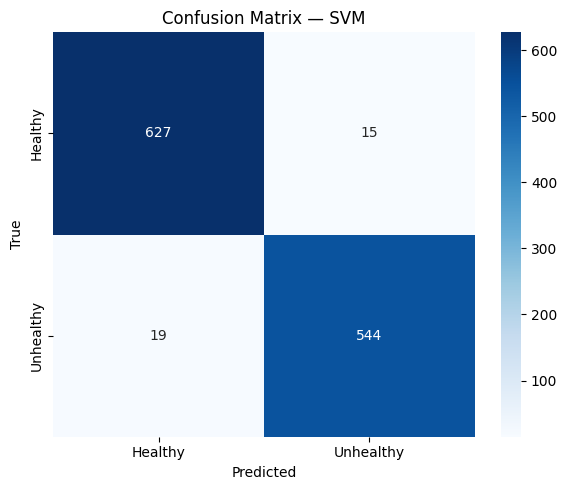


Top 5 Grid Search Results:


,param_kernel,param_C,param_gamma,mean_test_score,std_test_score,rank_test_score
0,rbf,10.0,scale,0.970374,0.001397,1
1,rbf,100.0,scale,0.970372,0.001804,2
2,rbf,1.0,scale,0.969115,0.002524,3
3,sigmoid,1.0,scale,0.965155,0.001905,4
4,poly,100.0,scale,0.954140,0.005166,5


In [11]:
# =========================
# Train & Evaluate: SVM + TF-IDF
# =========================
print("="*50)
print("SVM with TF-IDF")
print("="*50)

svm_tfidf = SVMClassifier(cv=5, scoring='f1_macro')
svm_tfidf.fit(X_train_tfidf, y_train)

#metrics_tfidf, y_pred_tfidf = svm_tfidf.evaluate(X_test_tfidf, y_test, label_encoder)
results_tfidf, y_pred_tfidf = svm_tfidf.evaluate(
    X_test_tfidf, y_test, label_encoder, model_name='SVM + TF-IDF'
)
svm_tfidf.plot_confusion_matrix(y_test, y_pred_tfidf, label_encoder)

print("\nTop 5 Grid Search Results:")
svm_tfidf.top_grid_results(5)

Accuracy: 97.68% | F1 Macro: 97.66%
Best config was also rbf, C=10, scale — same as CamemBERT
Healthy: precision 0.97, recall 0.98 → almost no Healthy samples misclassified
Unhealthy: precision 0.98, recall 0.97 → almost no Unhealthy samples misclassified
The tiny difference between precision and recall for both classes means the model is not biased toward either class

## 10. Cross-Validation (TF-IDF + Best SVM Params)

In [12]:
# =========================
# Cross-Validation on full dataset with best params from TF-IDF SVM
# =========================
tfidf_full = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_full     = tfidf_full.fit_transform(data['text_nostop'])
y_full     = data['encoded_label']

# Use best params found during GridSearch
best_svm_cv = SVC(**svm_tfidf.best_params)

cv_results = cross_validate(
    best_svm_cv, X_full, y_full,
    cv=5,
    scoring=['accuracy', 'f1_macro'],
    n_jobs=-1
)

print(f"Cross-Validation Results (5-fold, TF-IDF + Best SVM)")
print(f"  Mean Accuracy : {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"  Mean F1 Macro : {cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}")

Cross-Validation Results (5-fold, TF-IDF + Best SVM)
  Mean Accuracy : 0.9598 ± 0.0109
  Mean F1 Macro : 0.9596 ± 0.0110


This section performs a more robust evaluation of the TF-IDF + SVM combination on the full dataset (not just the 80% training split) using 5-fold cross-validation. The data is split into 5 equal parts; in each round, 4 parts are used for training and 1 for testing, rotating until every sample has been tested exactly once. We use the best hyperparameters found earlier by GridSearch to ensure a fair comparison. The mean and standard deviation of accuracy and F1 across the 5 folds are reported — a low standard deviation indicates the model is consistent and not sensitive to which particular subset it was tested on.


## 11. Model Comparison Summary

In [13]:
# =========================
# Final Results Table — TF-IDF Models
# =========================
final_table_tfidf = pd.concat(
    [
        results_tfidf,
    ],
    ignore_index=True
)

print("TF-IDF Model Performance Comparison")
final_table_tfidf

TF-IDF Model Performance Comparison


,Model,Class,Accuracy,Precision,Recall,F1-score,Support,Macro avg
0,SVM + TF-IDF,Healthy,0.97,0.97,0.98,0.97,642,0.97
1,,Unhealthy,,0.97,0.97,0.97,563,


In [14]:
# =========================
# Final Results Table — CamemBERT Models
# =========================
final_table_cam = pd.concat(
    [
        results_cam,
    ],
    ignore_index=True
)

print("CamemBERT Model Performance Comparison")
final_table_cam

CamemBERT Model Performance Comparison


,Model,Class,Accuracy,Precision,Recall,F1-score,Support,Macro avg
0,SVM + CamemBERT,Healthy,0.92,0.92,0.92,0.92,642,0.92
1,,Unhealthy,,0.91,0.91,0.91,563,


## 12. Model Comparison Summary

In [15]:
# =========================
# Model Comparison Summary
# =========================
comparison_table = pd.DataFrame([
    {
        'Vectorizer'  : 'CamemBERT',
        'Best Kernel' : svm_cam.best_params['kernel'],
        'Best C'      : svm_cam.best_params['C'],
        'Best Gamma'  : svm_cam.best_params['gamma'],
        'Accuracy'    : float(results_cam['Accuracy'].iloc[0]),
        'Macro F1'    : float(results_cam['Macro avg'].iloc[0]),
    },
    {
        'Vectorizer'  : 'TF-IDF',
        'Best Kernel' : svm_tfidf.best_params['kernel'],
        'Best C'      : svm_tfidf.best_params['C'],
        'Best Gamma'  : svm_tfidf.best_params['gamma'],
        'Accuracy'    : float(results_tfidf['Accuracy'].iloc[0]),
        'Macro F1'    : float(results_tfidf['Macro avg'].iloc[0]),
    }
])

print("Model Comparison")
print(comparison_table.to_string(index=False))
comparison_table

Model Comparison
Vectorizer Best Kernel  Best C Best Gamma  Accuracy  Macro F1
 CamemBERT        poly     100      scale      0.92      0.92
    TF-IDF         rbf      10      scale      0.97      0.97


,Vectorizer,Best Kernel,Best C,Best Gamma,Accuracy,Macro F1
0,CamemBERT,poly,100,scale,0.92,0.92
1,TF-IDF,rbf,10,scale,0.97,0.97


## 13. Export Results to Excel
> Saves SVM + CamemBERT, SVM + TF-IDF results, and model comparison to `SVM_Results.xlsx`
> Saves all GridSearch hyperparameters (full grid + best params) to `SVM_Hyperparameters.xlsx`

In [16]:
# =========================
# Export Results to Excel
# =========================
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

results_path = 'SVM_Results.xlsx'

with pd.ExcelWriter(results_path, engine='openpyxl') as writer:
    # Sheet 1: SVM + CamemBERT
    final_table_cam.to_excel(writer, sheet_name='SVM + CamemBERT', index=False)
    # Sheet 2: SVM + TF-IDF
    final_table_tfidf.to_excel(writer, sheet_name='SVM + TF-IDF', index=False)
    # Sheet 3: Comparison
    comparison_table.to_excel(writer, sheet_name='Model Comparison', index=False)

print(f"Results saved to {results_path}")

Results saved to SVM_Results.xlsx


In [17]:
# =========================
# Export Hyperparameters to Separate Excel
# =========================
hparam_path = 'SVM_Hyperparameters.xlsx'

# Build full GridSearch results for both models
hparams_cam   = svm_cam.top_grid_results(n=len(svm_cam.cv_results)).copy()
hparams_tfidf = svm_tfidf.top_grid_results(n=len(svm_tfidf.cv_results)).copy()

hparams_cam.columns   = ['Kernel', 'C', 'Gamma', 'Mean CV Score', 'Std CV Score', 'Rank']
hparams_tfidf.columns = ['Kernel', 'C', 'Gamma', 'Mean CV Score', 'Std CV Score', 'Rank']

# Best params summary
best_params_summary = pd.DataFrame([
    {'Model': 'SVM + CamemBERT', **svm_cam.best_params},
    {'Model': 'SVM + TF-IDF',    **svm_tfidf.best_params},
])

with pd.ExcelWriter(hparam_path, engine='openpyxl') as writer:
    best_params_summary.to_excel(writer, sheet_name='Best Params', index=False)
    hparams_cam.to_excel(writer,   sheet_name='GridSearch CamemBERT', index=False)
    hparams_tfidf.to_excel(writer, sheet_name='GridSearch TF-IDF',   index=False)

print(f"Hyperparameters saved to {hparam_path}")

Hyperparameters saved to SVM_Hyperparameters.xlsx


In [18]:
# =========================
# Save Train + Test Results
# =========================
import os, json, csv
from datetime import datetime
from sklearn.metrics import accuracy_score, f1_score, classification_report

os.makedirs("machine_learning_results", exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

def get_metrics(y_true, y_pred, le, model_name, split):
    report = classification_report(y_true, y_pred, target_names=le.classes_, output_dict=True)
    return {
        "timestamp":   timestamp,
        "model":       model_name,
        "split":       split,
        "accuracy":    round(accuracy_score(y_true, y_pred), 4),
        "f1_macro":    round(f1_score(y_true, y_pred, average="macro",    zero_division=0), 4),
        "f1_weighted": round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "healthy_precision":   round(report["Healthy"]["precision"],  4),
        "healthy_recall":      round(report["Healthy"]["recall"],     4),
        "healthy_f1":          round(report["Healthy"]["f1-score"],   4),
        "unhealthy_precision": round(report["Unhealthy"]["precision"],4),
        "unhealthy_recall":    round(report["Unhealthy"]["recall"],   4),
        "unhealthy_f1":        round(report["Unhealthy"]["f1-score"], 4),
    }

rows = []

# SVM + CamemBERT
rows.append(get_metrics(y_train, svm_cam.predict(X_train_cam),     label_encoder, "SVM+CamemBERT", "train"))
rows.append(get_metrics(y_test,  y_pred_cam,                        label_encoder, "SVM+CamemBERT", "test"))

# SVM + TF-IDF
rows.append(get_metrics(y_train, svm_tfidf.predict(X_train_tfidf), label_encoder, "SVM+TF-IDF", "train"))
rows.append(get_metrics(y_test,  y_pred_tfidf,                      label_encoder, "SVM+TF-IDF",  "test"))

# Save CSV
csv_path = "machine_learning_results/SVM_results.csv"
file_exists = os.path.exists(csv_path)
with open(csv_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    if not file_exists:
        writer.writeheader()
    writer.writerows(rows)

# Save JSON
json_path = f"machine_learning_results/SVM_results_{timestamp}.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(rows, f, indent=2)

# Print summary
print("\n" + "="*55)
print("  SVM RESULTS SAVED")
print("="*55)
for r in rows:
    print(f"  {r['model']:<20} {r['split']:<6} acc={r['accuracy']:.4f}  f1={r['f1_macro']:.4f}")
print(f"\n  CSV  → {csv_path}")
print(f"  JSON → {json_path}")



  SVM RESULTS SAVED
  SVM+CamemBERT        train  acc=0.9940  f1=0.9940
  SVM+CamemBERT        test   acc=0.9178  f1=0.9175
  SVM+TF-IDF           train  acc=0.9998  f1=0.9998
  SVM+TF-IDF           test   acc=0.9718  f1=0.9716

  CSV  → machine_learning_results/SVM_results.csv
  JSON → machine_learning_results/SVM_results_20260603_151534.json
